# Softmax

В этом ноутбуке описаны разные реализации софтмакс и графичнская демонстрация работы температуры. Весь латех написан руками, без нейронок так что могут быть ошибки

In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

torch.manual_seed(42)
np.random.seed(42)


In [ ]:
emb1 = torch.tensor([1, 2, 3, 4, 5], dtype=torch.float64)
d = emb1.size()[0]

d = 5 - размерность векторов QKV (в attention) или просто вектора логитов

# 1. Softmax

Softmax превращает вектор произвольных чисел в распределение вероятностей ($\sum_i softmax(x_i) = 1$).

$$\text{softmax}(x_i) = \frac{e^{x_i / T}}{\sum_j e^{x_j / T}}$$

Температура (T):
- $T \to 0$: распределение нулевое везде, кроме 1 точки (в ней 1)
- $T \to \infty$: распределение стремится к равномерному


In [ ]:
def softmax(vec, t=1.0):
    vec = vec - vec.max()
    exp_vec = torch.exp(vec / t)
    return exp_vec / exp_vec.sum()

tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64)
tensor(1.0000, dtype=torch.float64)


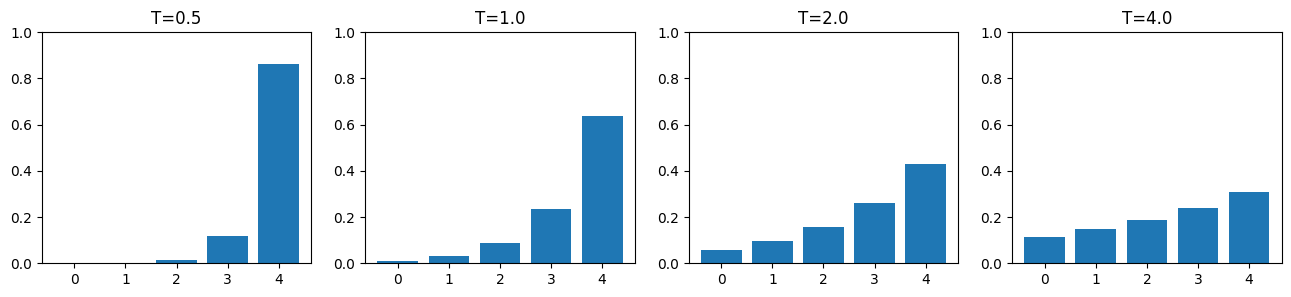

In [ ]:
temps = [0.5, 1.0, 2.0, 4.0]

fig, axes = plt.subplots(1, len(temps), figsize=(len(temps)*4, 3))
x = torch.arange(d, dtype=torch.float64)

for ax, T in zip(axes, temps):
    probs = softmax(emb1, t=T)
    print(sum(probs))
    ax.bar(x, probs.numpy())
    ax.set_title(f'T={T}')
    ax.set_ylim(0, 1)


# 2. Online softmax

Источник: https://x.com/jino_rohit/status/2042824461943022062

Вычиление softmax проходит в 4 этапа за O(n)
1. Проход по вектору и поиск макс. элемента $m = max(x)$
2. $\forall i$ вычисление $e^{(x_i-m)/T}$ - вычисление числителей
3. Сумма $\sum_i e^{(x_i-m)/T}$ - вычисление знаменателя
4. $\forall i$ числитель делится на знаменатель

$$ \text{softmax}(x_i) = \frac{ e^{(x_i - m) / T} }{\sum_j e^{(x_j - m) / T} }; \;\; m = max(x)$$

Все это можно сократить до 3 шагов
1. Вычисление знаменателя и макс. элемента x
2. Вычисление числителей $ e^{(x_i - m)/T} $
3. $\forall i$ числитель делится на знаменатель

За 1 шаг проходим циклом по вектору x:

$ m_i = max(m_{i-1}, x_i) $

$ d_i = d_{i-1} \ e^{(m_{i-1} - m_i)/T} + e^{(x_i - m_i)/T} $

где d - знаменатель, m - макс. элемент в векторе






In [ ]:
def online_softmax(x, t=1.0):
    curr_max = x[0]
    running_denom = torch.exp((x[0] - curr_max) / t)
    
    for i in range(1, x.shape[0]):
        if x[i] > curr_max:
            old_max = curr_max
            curr_max = x[i]
            running_denom = running_denom * torch.exp((old_max - curr_max) / t) + torch.exp((x[i] - curr_max) / t)
        else:
            running_denom += torch.exp((x[i] - curr_max) / t)
    
    num = torch.exp((x - curr_max) / t)
    
    result = num / running_denom

    return result

tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64)
tensor(1.0000, dtype=torch.float64)


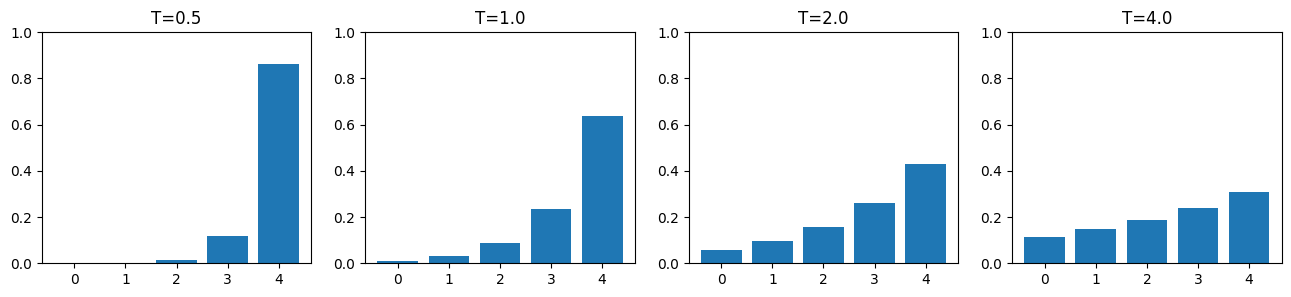

In [ ]:
temps = [0.5, 1.0, 2.0, 4.0]

fig, axes = plt.subplots(1, len(temps), figsize=(len(temps)*4, 3))
x = torch.arange(d, dtype=torch.float64)

for ax, T in zip(axes, temps):
    probs = online_softmax(emb1, t=T)
    print(sum(probs))
    ax.bar(x, probs.numpy())
    ax.set_title(f'T={T}')
    ax.set_ylim(0, 1)

# 3. Blocked softmax

Чтобы распараллелить вычисления, можно обрабатывать вектор частями (блоками), а затем собрать все обратно

Вычислим делитель и максимальный элемент для каждого блока, а затем масштабируем используя максимальный элемент во всем массиве




In [ ]:
def block_stats(x, t=1.0):
    curr_max = x[0]
    running_denom = torch.exp((x[0] - curr_max) / t)
    
    for i in range(1, x.shape[0]):
        if x[i] > curr_max:
            old_max = curr_max
            curr_max = x[i]
            running_denom = running_denom * torch.exp((old_max - curr_max) / t) + torch.exp((x[i] - curr_max) / t)
        else:
            running_denom += torch.exp((x[i] - curr_max) / t)

    return curr_max, running_denom
    

### Просто для демонстрации напишем функцию без многопотока

In [ ]:
def blocked_softmax(x, block_len, t=1.0):
    blocks = x.split(block_len)

    max_vals, denoms = [], []
    for b in blocks:
        m, d = block_stats(b, t)
        max_vals.append(m)
        denoms.append(d)
        
    final_m = max(max_vals)
    final_d = sum(d * torch.exp((m - final_m) / t) for m, d in zip(max_vals, denoms))
    
    return torch.exp((x - final_m) / t) / final_d

tensor(1.0000, dtype=torch.float64)
tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64)


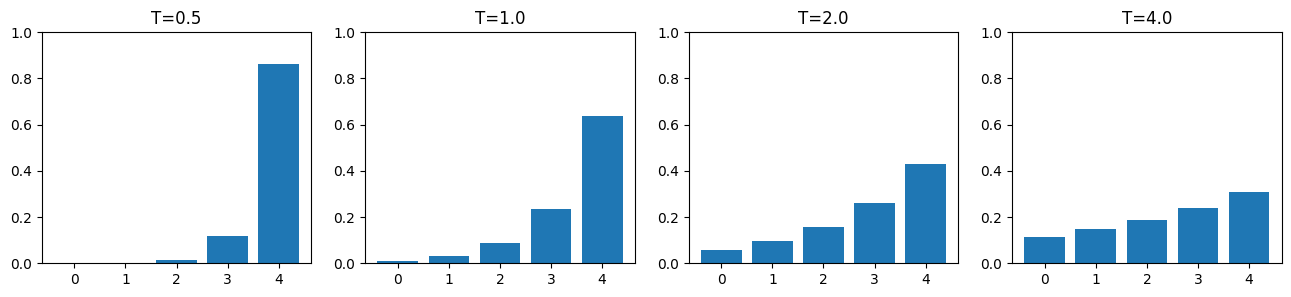

In [ ]:
temps = [0.5, 1.0, 2.0, 4.0]

fig, axes = plt.subplots(1, len(temps), figsize=(len(temps)*4, 3))
x = torch.arange(d, dtype=torch.float64)

for ax, T in zip(axes, temps):
    probs = blocked_softmax(emb1, 3, t=T)
    print(sum(probs))
    ax.bar(x, probs.numpy())
    ax.set_title(f'T={T}')
    ax.set_ylim(0, 1)